# Normalized Prophet Forecasting for All Electricity Clients

This notebook trains a Prophet baseline model for every client column in `dataset/LD2011_2014.txt`, excluding the timestamp column, using normalized data.

It follows the same logic as the all-client Prophet notebook:

- load all 370 client load series,
- use activation-aware preprocessing for late-starting clients,
- resample 15-minute readings to hourly values,
- normalize each client series,
- fit one Prophet model per client,
- evaluate on a final holdout window,
- generate future forecasts and save artifacts.

The main difference is that Prophet is fitted on normalized target values. Forecasts are then inverse-transformed back to the original load scale for evaluation and interpretation.


## 1. Setup

In [1]:
from pathlib import Path
import os
import time
import warnings
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

warnings.filterwarnings("ignore")
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("prophet").setLevel(logging.WARNING)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")

In [2]:
# Paths
DATA_PATH = Path("dataset/LD2011_2014.txt")
OUTPUT_DIR = Path("outputs/prophet_all_normalized")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Data frequencies
RAW_FREQ = "15min"
FORECAST_FREQ = "h"       # Hourly aggregation keeps the main seasonalities and makes 370 Prophet fits practical.
RESAMPLE_METHOD = "mean"

# Forecasting setup
TEST_DAYS = 30
FUTURE_DAYS = 7
MIN_HISTORY_DAYS = 90      # Shorter histories are marked as skipped instead of forcing an unreliable baseline.

# Preprocessing setup based on deep EDA findings
REPLACE_NON_POSITIVE_WITH_NA = True
INTERPOLATE_MISSING = True
CLIP_EXTREME_OUTLIERS = True
LOWER_CLIP_Q = 0.001
UPPER_CLIP_Q = 0.999

# Normalization setup
# The model uses z-score normalization per client: y_norm = (y - mean) / std.
# Holdout scalers are fitted on train only. Final forecast scalers are fitted on all active history.
NORMALIZATION_METHOD = "zscore"
MIN_STD = 1e-8

# Full run control
# Default is 0, which means use all client columns. Set to a small number for a quick smoke test.
SMOKE_TEST_N = int(os.getenv("PROPHET_ALL_NORMALIZED_SMOKE_N", "0"))

assert DATA_PATH.exists(), "Dataset not found: {}".format(DATA_PATH)

## 2. Load and Validate the Full Dataset

In [3]:
raw_df = pd.read_csv(
    DATA_PATH,
    delimiter=";",
    decimal=",",
    parse_dates=[0],
    index_col=0,
    low_memory=False,
)

raw_df.index.name = "ds"
raw_df = raw_df.sort_index()
raw_df = raw_df[~raw_df.index.duplicated(keep="last")]
raw_df = raw_df.apply(pd.to_numeric, errors="coerce")

target_columns = list(raw_df.columns)

print(f"Shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]:,} client columns")
print(f"Time range: {raw_df.index.min()} to {raw_df.index.max()}")
print(f"Missing values: {raw_df.isna().sum().sum():,}")
print(f"Most common time step: {pd.Series(raw_df.index).diff().dropna().mode().iloc[0]}")
print(f"Non-{RAW_FREQ} gaps: {(pd.Series(raw_df.index).diff().dropna() != pd.Timedelta(RAW_FREQ)).sum():,}")
raw_df.head()

Shape: 140,256 rows x 370 client columns
Time range: 2011-01-01 00:15:00 to 2015-01-01 00:00:00
Missing values: 0
Most common time step: 0 days 00:15:00
Non-15min gaps: 0


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
selected_columns = target_columns if SMOKE_TEST_N <= 0 else target_columns[:SMOKE_TEST_N]

print(f"Total available client columns: {len(target_columns)}")
print(f"Columns selected for this run: {len(selected_columns)}")
if SMOKE_TEST_N > 0:
    print(f"Smoke-test mode is active: first {SMOKE_TEST_N} columns only")

Total available client columns: 370
Columns selected for this run: 370


## 3. Client Activity Summary

The deeper EDA showed that many clients are late starters. Leading zero stretches are therefore treated as inactive history rather than true zero consumption.


In [5]:
activity_rows = []
for col in target_columns:
    positive_mask = raw_df[col] > 0
    first_active = raw_df.index[positive_mask.argmax()] if positive_mask.any() else pd.NaT
    last_active = raw_df.index[len(positive_mask) - positive_mask[::-1].argmax() - 1] if positive_mask.any() else pd.NaT
    activity_rows.append(
        {
            "client": col,
            "first_active": first_active,
            "last_active": last_active,
            "positive_readings": int(positive_mask.sum()),
            "zero_fraction": float((raw_df[col] == 0).mean()),
            "mean_load": float(raw_df[col].mean()),
            "total_load": float(raw_df[col].sum()),
        }
    )

activity_df = pd.DataFrame(activity_rows).set_index("client")
activity_df["active_from_day_1"] = activity_df["first_active"] <= raw_df.index.min() + pd.Timedelta(days=1)
activity_df["history_days_after_first_active"] = (
    raw_df.index.max() - activity_df["first_active"]
).dt.total_seconds() / (24 * 3600)

print(f"Always active clients: {activity_df['active_from_day_1'].sum()}")
print(f"Late starters: {(~activity_df['active_from_day_1']).sum()}")
print(f"Never active clients: {activity_df['first_active'].isna().sum()}")
activity_df.sort_values("total_load", ascending=False).head(10)

Always active clients: 158
Late starters: 212
Never active clients: 0


,first_active,last_active,positive_readings,zero_fraction,mean_load,total_load,active_from_day_1,history_days_after_first_active
client,,,,,,,,
MT_362,2012-01-01 00:15:00,2015-01-01,105138,0.250385,37607.987537,5.274746e+09,False,1095.989583
MT_196,2011-01-01 00:15:00,2015-01-01,140234,0.000157,20744.150874,2.909492e+09,True,1460.989583
MT_279,2011-01-01 00:15:00,2015-01-01,140160,0.000684,12038.971232,1.688538e+09,True,1460.989583
MT_370,2013-01-01 00:15:00,2015-01-01,69927,0.501433,8722.355145,1.223363e+09,False,729.989583
MT_208,2011-01-01 00:15:00,2015-01-01,140234,0.000157,6662.030067,9.343897e+08,True,1460.989583
MT_228,2011-01-01 00:15:00,2015-01-01,140244,0.000086,5782.656826,8.110523e+08,True,1460.989583
MT_220,2011-01-01 00:15:00,2015-01-01,140241,0.000107,2951.449898,4.139586e+08,True,1460.989583
MT_364,2012-01-01 00:15:00,2015-01-01,105157,0.250250,2940.031734,4.123571e+08,False,1095.989583
MT_194,2011-01-01 00:15:00,2015-01-01,140232,0.000171,2675.000006,3.751848e+08,True,1460.989583


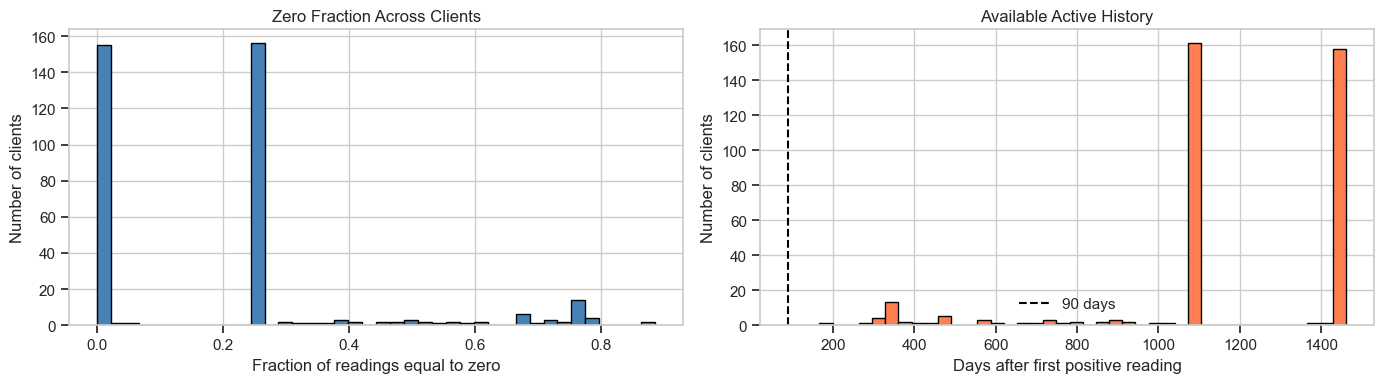

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

activity_df["zero_fraction"].hist(bins=40, ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Zero Fraction Across Clients")
axes[0].set_xlabel("Fraction of readings equal to zero")
axes[0].set_ylabel("Number of clients")

activity_df["history_days_after_first_active"].hist(bins=40, ax=axes[1], color="coral", edgecolor="black")
axes[1].axvline(MIN_HISTORY_DAYS, color="black", linestyle="--", label=f"{MIN_HISTORY_DAYS} days")
axes[1].set_title("Available Active History")
axes[1].set_xlabel("Days after first positive reading")
axes[1].set_ylabel("Number of clients")
axes[1].legend()

plt.tight_layout()

## 4. Activation-Aware Preprocessing

Preprocessing decisions:

- enforce a regular 15-minute grid,
- replace non-positive readings with missing values because EDA found activation-related zero stretches and zero DST/outage artifacts,
- resample each client to hourly mean load,
- interpolate missing values only after each client's first active timestamp,
- optionally clip extreme hourly outliers per client using conservative quantiles.

The resulting hourly table can contain `NaN` before each late-starting client's activation date. Those rows are dropped per client inside the modelling loop.


In [7]:
def preprocess_all_clients(raw: pd.DataFrame, activity: pd.DataFrame) -> pd.DataFrame:
    regular = raw.asfreq(RAW_FREQ)
    cleaned = regular.copy()

    if REPLACE_NON_POSITIVE_WITH_NA:
        cleaned = cleaned.mask(cleaned <= 0)

    if RESAMPLE_METHOD == "mean":
        hourly = cleaned.resample(FORECAST_FREQ).mean()
    elif RESAMPLE_METHOD == "sum":
        hourly = cleaned.resample(FORECAST_FREQ).sum(min_count=1)
    else:
        raise ValueError("RESAMPLE_METHOD must be either 'mean' or 'sum'.")

    hourly.index.name = "ds"
    processed = hourly.copy()

    for col in processed.columns:
        first_active = activity.loc[col, "first_active"]
        if pd.isna(first_active):
            processed[col] = np.nan
            continue

        active_start = first_active.floor(FORECAST_FREQ)
        s = processed[col].copy()
        s.loc[s.index < active_start] = np.nan

        active_part = s.loc[s.index >= active_start].copy()
        if INTERPOLATE_MISSING:
            active_part = active_part.interpolate(method="time").ffill().bfill()

        if CLIP_EXTREME_OUTLIERS and active_part.notna().sum() > 10:
            lower, upper = active_part.quantile([LOWER_CLIP_Q, UPPER_CLIP_Q])
            active_part = active_part.clip(lower=lower, upper=upper)

        s.loc[s.index >= active_start] = active_part
        processed[col] = s

    return processed

processed_hourly = preprocess_all_clients(raw_df, activity_df)

print(f"Processed hourly shape: {processed_hourly.shape}")
print(f"Date range: {processed_hourly.index.min()} to {processed_hourly.index.max()}")
print(f"Total missing hourly cells: {processed_hourly.isna().sum().sum():,}")
processed_hourly.head()

Processed hourly shape: (35065, 370)
Date range: 2011-01-01 00:00:00 to 2015-01-01 00:00:00
Total missing hourly cells: 2,489,562


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
preprocess_summary = activity_df.copy()
preprocess_summary["hourly_non_missing"] = processed_hourly.notna().sum()
preprocess_summary["hourly_missing"] = processed_hourly.isna().sum()
preprocess_summary["hourly_start"] = processed_hourly.apply(lambda s: s.first_valid_index())
preprocess_summary["hourly_end"] = processed_hourly.apply(lambda s: s.last_valid_index())
preprocess_summary["hourly_history_days"] = (
    preprocess_summary["hourly_end"] - preprocess_summary["hourly_start"]
).dt.total_seconds() / (24 * 3600)
preprocess_summary["eligible_for_prophet"] = preprocess_summary["hourly_history_days"] >= MIN_HISTORY_DAYS

print(preprocess_summary["eligible_for_prophet"].value_counts().rename(index={True: "eligible", False: "not eligible"}))
preprocess_summary.sort_values("total_load", ascending=False).head(10)

eligible_for_prophet
eligible    370
Name: count, dtype: int64


,first_active,last_active,positive_readings,zero_fraction,mean_load,total_load,active_from_day_1,history_days_after_first_active,hourly_non_missing,hourly_missing,hourly_start,hourly_end,hourly_history_days,eligible_for_prophet
client,,,,,,,,,,,,,,
MT_362,2012-01-01 00:15:00,2015-01-01,105138,0.250385,37607.987537,5.274746e+09,False,1095.989583,26305,8760,2012-01-01,2015-01-01,1096.0,True
MT_196,2011-01-01 00:15:00,2015-01-01,140234,0.000157,20744.150874,2.909492e+09,True,1460.989583,35065,0,2011-01-01,2015-01-01,1461.0,True
MT_279,2011-01-01 00:15:00,2015-01-01,140160,0.000684,12038.971232,1.688538e+09,True,1460.989583,35065,0,2011-01-01,2015-01-01,1461.0,True
MT_370,2013-01-01 00:15:00,2015-01-01,69927,0.501433,8722.355145,1.223363e+09,False,729.989583,17521,17544,2013-01-01,2015-01-01,730.0,True
MT_208,2011-01-01 00:15:00,2015-01-01,140234,0.000157,6662.030067,9.343897e+08,True,1460.989583,35065,0,2011-01-01,2015-01-01,1461.0,True
MT_228,2011-01-01 00:15:00,2015-01-01,140244,0.000086,5782.656826,8.110523e+08,True,1460.989583,35065,0,2011-01-01,2015-01-01,1461.0,True
MT_220,2011-01-01 00:15:00,2015-01-01,140241,0.000107,2951.449898,4.139586e+08,True,1460.989583,35065,0,2011-01-01,2015-01-01,1461.0,True
MT_364,2012-01-01 00:15:00,2015-01-01,105157,0.250250,2940.031734,4.123571e+08,False,1095.989583,26305,8760,2012-01-01,2015-01-01,1096.0,True
MT_194,2011-01-01 00:15:00,2015-01-01,140232,0.000171,2675.000006,3.751848e+08,True,1460.989583,35065,0,2011-01-01,2015-01-01,1461.0,True


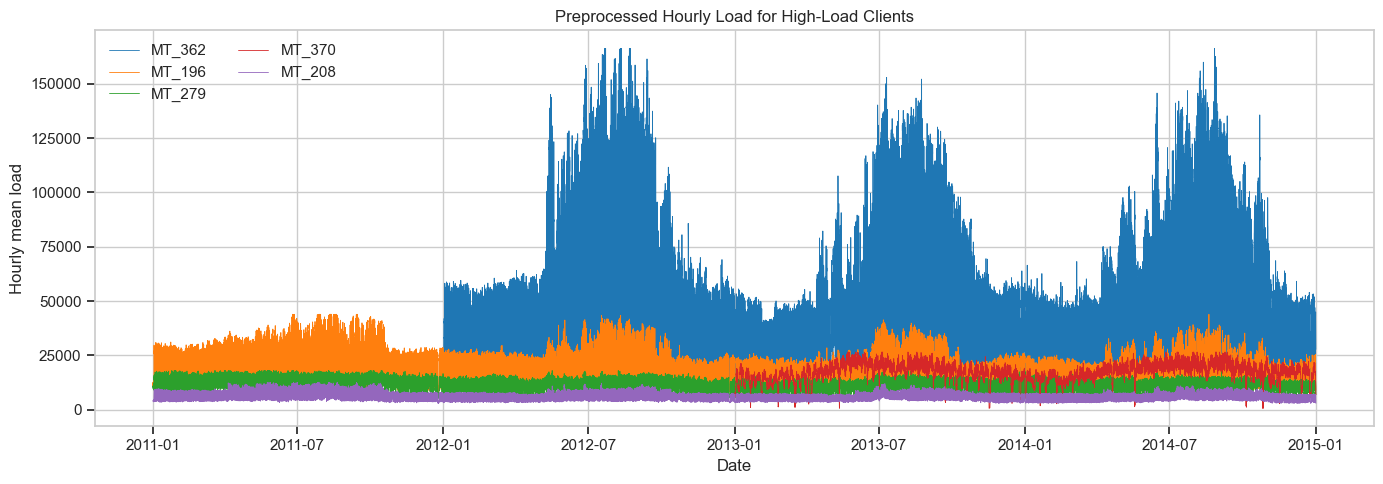

In [9]:
top_clients = preprocess_summary.sort_values("total_load", ascending=False).head(10).index.tolist()
plot_cols = top_clients[:5]

fig, ax = plt.subplots(figsize=(14, 5))
for col in plot_cols:
    ax.plot(processed_hourly.index, processed_hourly[col], linewidth=0.6, label=col)
ax.set_title("Preprocessed Hourly Load for High-Load Clients")
ax.set_xlabel("Date")
ax.set_ylabel("Hourly mean load")
ax.legend(ncol=2)
plt.tight_layout()

## 5. Normalize the Preprocessed Data

The normalized data uses per-client z-score scaling:

`y_norm = (y - mean) / std`

This puts clients with very different load magnitudes on a comparable scale for Prophet. The table below is useful for diagnostics and visualization.

For modelling, the holdout evaluation fits the scaler on the training period only, then applies it to the holdout period. This avoids leakage from the test window.


In [10]:
def fit_zscore_scaler(values: pd.Series) -> dict:
    clean = values.dropna().astype(float)
    mean = clean.mean()
    std = clean.std(ddof=0)
    if not np.isfinite(std) or std < MIN_STD:
        std = np.nan
    return {"mean": float(mean), "std": float(std)}


def transform_values(values: pd.Series, scaler: dict) -> pd.Series:
    return (values.astype(float) - scaler["mean"]) / scaler["std"]


def inverse_transform_values(values: pd.Series, scaler: dict) -> pd.Series:
    return values.astype(float) * scaler["std"] + scaler["mean"]


normalization_rows = []
normalized_hourly = processed_hourly.copy()

for col in processed_hourly.columns:
    scaler = fit_zscore_scaler(processed_hourly[col])
    normalization_rows.append({"client": col, "mean": scaler["mean"], "std": scaler["std"]})
    if np.isfinite(scaler["std"]):
        normalized_hourly[col] = transform_values(processed_hourly[col], scaler)
    else:
        normalized_hourly[col] = np.nan

normalization_df = pd.DataFrame(normalization_rows).set_index("client")
normalization_df.to_csv(OUTPUT_DIR / "prophet_all_normalized_scalers_full_history.csv")

print(f"Normalized hourly shape: {normalized_hourly.shape}")
print(f"Clients with valid full-history scaler: {normalization_df['std'].notna().sum()} / {len(normalization_df)}")
normalization_df.head()

Normalized hourly shape: (35065, 370)
Clients with valid full-history scaler: 370 / 370


,mean,std
client,,
MT_001,5.379824,5.991407
MT_002,27.681427,6.371274
MT_003,3.899438,12.260924
MT_004,109.563132,38.131270
MT_005,49.645025,17.410975


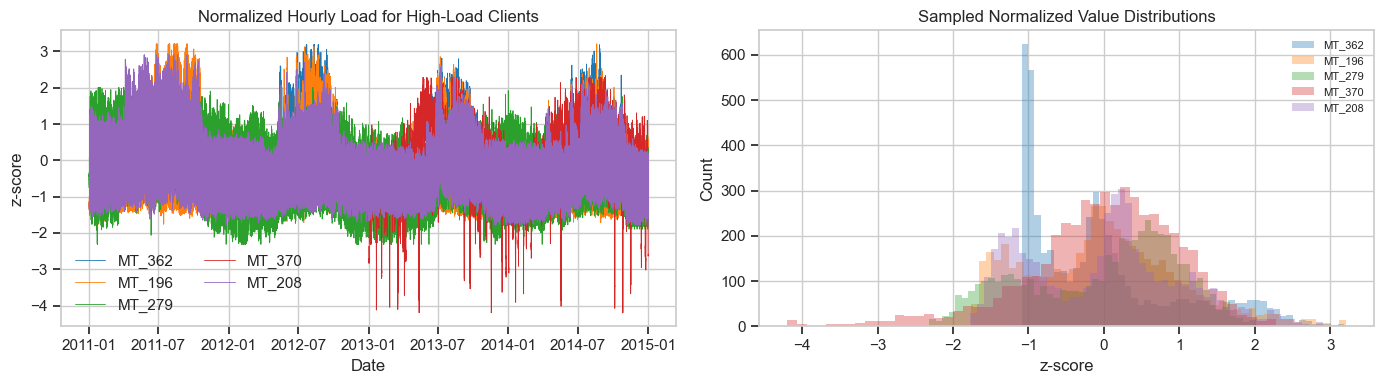

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for col in plot_cols:
    axes[0].plot(normalized_hourly.index, normalized_hourly[col], linewidth=0.6, label=col)
axes[0].set_title("Normalized Hourly Load for High-Load Clients")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("z-score")
axes[0].legend(ncol=2)

for col in plot_cols:
    sample = normalized_hourly[col].dropna().sample(min(5000, normalized_hourly[col].dropna().shape[0]), random_state=42)
    axes[1].hist(sample, bins=50, alpha=0.35, label=col)
axes[1].set_title("Sampled Normalized Value Distributions")
axes[1].set_xlabel("z-score")
axes[1].set_ylabel("Count")
axes[1].legend(fontsize=8)

plt.tight_layout()

## 6. Prophet Modelling Functions

One independent Prophet model is fitted for each client on normalized `y` values.

The model includes:

- sub-daily seasonalities inspired by the spectral EDA: 6-hour, 8-hour, and 12-hour patterns,
- built-in daily, weekly, and yearly seasonalities,
- an additional monthly seasonality.

Holdout metrics are reported on the original load scale after inverse transformation. Normalized MAE/RMSE are also saved as diagnostic metrics.


In [12]:
try:
    from prophet import Prophet
except ImportError as exc:
    raise ImportError(
        "Prophet is required for this notebook. Install it with `%pip install prophet` and rerun."
    ) from exc

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = lambda iterable, **kwargs: iterable

In [13]:
def build_prophet_model() -> Prophet:
    model = Prophet(
        growth="linear",
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=True,
        seasonality_mode="additive",
        seasonality_prior_scale=10.0,
        changepoint_prior_scale=0.05,
        interval_width=0.80,
    )
    model.add_seasonality(name="six_hour", period=0.25, fourier_order=3)
    model.add_seasonality(name="eight_hour", period=1 / 3, fourier_order=3)
    model.add_seasonality(name="semi_daily", period=0.5, fourier_order=3)
    model.add_seasonality(name="monthly", period=30.5, fourier_order=5)
    return model


def prepare_client_frame(processed: pd.DataFrame, client: str) -> pd.DataFrame:
    client_df = processed[[client]].dropna().rename(columns={client: "y"}).reset_index()
    client_df["y"] = client_df["y"].astype(float)
    return client_df


def evaluate_predictions(actual: pd.Series, predicted: pd.Series) -> dict:
    actual = actual.astype(float)
    predicted = predicted.astype(float).clip(lower=0)
    absolute_error = np.abs(actual - predicted)
    denominator = np.abs(actual).sum()
    return {
        "mae": mean_absolute_error(actual, predicted),
        "rmse": np.sqrt(mean_squared_error(actual, predicted)),
        "mape_pct": mean_absolute_percentage_error(actual, predicted) * 100,
        "wape_pct": np.nan if denominator == 0 else absolute_error.sum() / denominator * 100,
    }


def add_inverse_scaled_forecast_columns(target_df: pd.DataFrame, prophet_forecast: pd.DataFrame, scaler: dict) -> pd.DataFrame:
    result = target_df.copy()
    for col in ["yhat", "yhat_lower", "yhat_upper"]:
        result[f"{col}_norm"] = prophet_forecast[col].values
        result[col] = inverse_transform_values(prophet_forecast[col], scaler).clip(lower=0).values
    return result


def fit_evaluate_forecast_client(client: str, processed: pd.DataFrame) -> tuple[dict, pd.DataFrame, pd.DataFrame]:
    client_df = prepare_client_frame(processed, client)
    history_days = (client_df["ds"].max() - client_df["ds"].min()).total_seconds() / (24 * 3600) if len(client_df) else 0

    base_result = {
        "client": client,
        "status": "ok",
        "n_obs": len(client_df),
        "history_days": history_days,
        "train_rows": 0,
        "test_rows": 0,
        "fit_seconds_holdout": np.nan,
        "fit_seconds_final": np.nan,
        "fit_seconds_total": np.nan,
        "train_mean": np.nan,
        "train_std": np.nan,
        "final_mean": np.nan,
        "final_std": np.nan,
        "mae": np.nan,
        "rmse": np.nan,
        "mape_pct": np.nan,
        "wape_pct": np.nan,
        "mae_norm": np.nan,
        "rmse_norm": np.nan,
        "error": "",
    }

    if history_days < MIN_HISTORY_DAYS or len(client_df) < 24 * MIN_HISTORY_DAYS:
        base_result["status"] = "skipped"
        base_result["error"] = f"Less than {MIN_HISTORY_DAYS} days of active hourly history"
        return base_result, pd.DataFrame(), pd.DataFrame()

    cutoff = client_df["ds"].max() - pd.Timedelta(days=TEST_DAYS)
    train_df = client_df[client_df["ds"] <= cutoff].copy()
    test_df = client_df[client_df["ds"] > cutoff].copy()

    if len(train_df) < 24 * (MIN_HISTORY_DAYS - TEST_DAYS) or len(test_df) < 24:
        base_result["status"] = "skipped"
        base_result["error"] = "Not enough train/test observations after holdout split"
        return base_result, pd.DataFrame(), pd.DataFrame()

    train_scaler = fit_zscore_scaler(train_df["y"])
    if not np.isfinite(train_scaler["std"]):
        base_result["status"] = "skipped"
        base_result["error"] = "Training series has near-zero variance after preprocessing"
        return base_result, pd.DataFrame(), pd.DataFrame()

    train_norm = train_df[["ds"]].copy()
    train_norm["y"] = transform_values(train_df["y"], train_scaler)
    test_norm = test_df[["ds"]].copy()
    test_norm["y"] = transform_values(test_df["y"], train_scaler)

    start_time = time.time()
    model = build_prophet_model()
    model.fit(train_norm)
    fit_seconds_holdout = time.time() - start_time

    holdout_forecast_norm = model.predict(test_df[["ds"]])
    holdout_df = test_df.copy()
    holdout_df["y_norm"] = test_norm["y"].values
    holdout_df = add_inverse_scaled_forecast_columns(holdout_df, holdout_forecast_norm, train_scaler)
    holdout_df.insert(0, "client", client)

    metrics = evaluate_predictions(holdout_df["y"], holdout_df["yhat"])
    metrics_norm = {
        "mae_norm": mean_absolute_error(holdout_df["y_norm"], holdout_df["yhat_norm"]),
        "rmse_norm": np.sqrt(mean_squared_error(holdout_df["y_norm"], holdout_df["yhat_norm"])),
    }

    final_scaler = fit_zscore_scaler(client_df["y"])
    if not np.isfinite(final_scaler["std"]):
        base_result["status"] = "skipped"
        base_result["error"] = "Full series has near-zero variance after preprocessing"
        return base_result, pd.DataFrame(), pd.DataFrame()

    full_norm = client_df[["ds"]].copy()
    full_norm["y"] = transform_values(client_df["y"], final_scaler)

    start_time = time.time()
    final_model = build_prophet_model()
    final_model.fit(full_norm)
    fit_seconds_final = time.time() - start_time

    future = final_model.make_future_dataframe(periods=FUTURE_DAYS * 24, freq=FORECAST_FREQ, include_history=False)
    future_forecast_norm = final_model.predict(future)

    future_df = future.copy()
    for col in ["yhat", "yhat_lower", "yhat_upper"]:
        future_df[f"{col}_norm"] = future_forecast_norm[col].values
        future_df[col] = inverse_transform_values(future_forecast_norm[col], final_scaler).clip(lower=0).values

    component_cols = ["trend", "six_hour", "eight_hour", "semi_daily", "daily", "weekly", "monthly", "yearly"]
    for col in component_cols:
        future_df[f"{col}_norm"] = future_forecast_norm[col].values

    future_df.insert(0, "client", client)

    base_result.update(metrics)
    base_result.update(metrics_norm)
    base_result.update(
        {
            "train_rows": len(train_df),
            "test_rows": len(test_df),
            "fit_seconds_holdout": fit_seconds_holdout,
            "fit_seconds_final": fit_seconds_final,
            "fit_seconds_total": fit_seconds_holdout + fit_seconds_final,
            "train_mean": train_scaler["mean"],
            "train_std": train_scaler["std"],
            "final_mean": final_scaler["mean"],
            "final_std": final_scaler["std"],
        }
    )
    return base_result, holdout_df, future_df

## 7. Train Normalized Prophet for All Client Columns

With the default configuration, this cell fits normalized Prophet models for all 370 clients. Prophet is fitted independently for each client and then refitted on the full normalized history for the future forecast.

For a quick check, run the notebook with `PROPHET_ALL_NORMALIZED_SMOKE_N=3` in the environment or set `SMOKE_TEST_N = 3` in the configuration cell.


In [14]:
results = []
holdout_frames = []
future_frames = []

run_columns = selected_columns
print(f"Starting normalized Prophet run for {len(run_columns)} client columns...")
print(f"Outputs will be saved in: {OUTPUT_DIR.resolve()}")

for i, client in enumerate(tqdm(run_columns, desc="Normalized Prophet models"), start=1):
    try:
        result, holdout_df, future_df = fit_evaluate_forecast_client(client, processed_hourly)
    except Exception as exc:
        result = {
            "client": client,
            "status": "failed",
            "n_obs": np.nan,
            "history_days": np.nan,
            "train_rows": 0,
            "test_rows": 0,
            "fit_seconds_holdout": np.nan,
            "fit_seconds_final": np.nan,
            "fit_seconds_total": np.nan,
            "train_mean": np.nan,
            "train_std": np.nan,
            "final_mean": np.nan,
            "final_std": np.nan,
            "mae": np.nan,
            "rmse": np.nan,
            "mape_pct": np.nan,
            "wape_pct": np.nan,
            "mae_norm": np.nan,
            "rmse_norm": np.nan,
            "error": repr(exc),
        }
        holdout_df = pd.DataFrame()
        future_df = pd.DataFrame()

    results.append(result)
    if not holdout_df.empty:
        holdout_frames.append(holdout_df)
    if not future_df.empty:
        future_frames.append(future_df)

    # Write incremental metrics so a long run still leaves useful partial results.
    pd.DataFrame(results).to_csv(OUTPUT_DIR / "prophet_all_normalized_metrics_partial.csv", index=False)

metrics_df = pd.DataFrame(results).sort_values(["status", "wape_pct"], na_position="last").reset_index(drop=True)
holdout_predictions_df = pd.concat(holdout_frames, ignore_index=True) if holdout_frames else pd.DataFrame()
future_forecasts_df = pd.concat(future_frames, ignore_index=True) if future_frames else pd.DataFrame()

metrics_df.to_csv(OUTPUT_DIR / "prophet_all_normalized_metrics.csv", index=False)
holdout_predictions_df.to_csv(OUTPUT_DIR / "prophet_all_normalized_holdout_predictions.csv", index=False)
future_forecasts_df.to_csv(OUTPUT_DIR / "prophet_all_normalized_future_forecasts.csv", index=False)

print("Run complete.")
print(metrics_df["status"].value_counts(dropna=False))
metrics_df.head(10)

Starting normalized Prophet run for 370 client columns...
Outputs will be saved in: /Users/adriannabartoszek/Documents/studia/semestr VI - deg/DL/p/outputs/prophet_all_normalized


Normalized Prophet models:   0%|          | 0/370 [00:00<?, ?it/s]

15:23:38 - cmdstanpy - INFO - Chain [1] start processing
15:23:45 - cmdstanpy - INFO - Chain [1] done processing
15:23:47 - cmdstanpy - INFO - Chain [1] start processing
15:23:55 - cmdstanpy - INFO - Chain [1] done processing
15:23:57 - cmdstanpy - INFO - Chain [1] start processing
15:24:03 - cmdstanpy - INFO - Chain [1] done processing
15:24:04 - cmdstanpy - INFO - Chain [1] start processing
15:24:10 - cmdstanpy - INFO - Chain [1] done processing
15:24:11 - cmdstanpy - INFO - Chain [1] start processing
15:24:26 - cmdstanpy - INFO - Chain [1] done processing
15:24:27 - cmdstanpy - INFO - Chain [1] start processing
15:24:45 - cmdstanpy - INFO - Chain [1] done processing
15:24:46 - cmdstanpy - INFO - Chain [1] start processing
15:24:50 - cmdstanpy - INFO - Chain [1] done processing
15:24:52 - cmdstanpy - INFO - Chain [1] start processing
15:24:56 - cmdstanpy - INFO - Chain [1] done processing
15:24:58 - cmdstanpy - INFO - Chain [1] start processing
15:25:01 - cmdstanpy - INFO - Chain [1]

Run complete.
status
ok    370
Name: count, dtype: int64


,client,status,n_obs,history_days,train_rows,test_rows,fit_seconds_holdout,fit_seconds_final,fit_seconds_total,train_mean,train_std,final_mean,final_std,mae,rmse,mape_pct,wape_pct,mae_norm,rmse_norm,error
0,MT_145,ok,26305,1096.000000,25585,720,6.354554,10.575418,16.929972,77.634804,5.858796,77.339140,6.064075,2.848640,3.342281,4.341786,4.262340,0.486216,0.570472,
1,MT_152,ok,17521,730.000000,16801,720,2.978299,3.100457,6.078756,1058.116088,110.828453,1059.853628,110.144213,49.976797,60.724842,4.532879,4.541699,0.450938,0.547917,
2,MT_146,ok,26145,1089.333333,25425,720,9.386896,6.515814,15.902710,84.055802,8.011038,84.010513,7.928885,4.453816,5.203722,5.503990,5.404380,0.555960,0.649569,
3,MT_148,ok,26305,1096.000000,25585,720,5.753091,6.535393,12.288484,342.939015,25.924561,343.231515,25.747173,21.659161,23.868392,6.105088,6.124888,0.835469,0.920686,
4,MT_229,ok,35065,1461.000000,34345,720,13.160068,9.763398,22.923465,974.272348,271.871340,974.450407,270.768875,60.774564,85.880010,6.966348,6.182912,0.223542,0.315885,
5,MT_150,ok,26305,1096.000000,25585,720,10.168497,950.975682,961.144179,27.572112,4.246422,27.453370,4.254191,1.439113,1.692676,6.186405,6.194017,0.338900,0.398612,
6,MT_147,ok,26305,1096.000000,25585,720,9.868193,9.990354,19.858547,2743.952340,251.247511,2734.436879,254.415418,159.585376,184.700845,6.670322,6.659637,0.635172,0.735135,
7,MT_182,ok,35065,1461.000000,34345,720,24.008548,24.287578,48.296126,52.932042,15.086034,52.784645,15.105051,3.192722,4.951690,7.831448,6.978077,0.211634,0.328230,
8,MT_369,ok,26305,1096.000000,25585,720,5.490493,5.784527,11.275021,835.782465,138.117326,833.630147,137.465374,53.232382,68.206951,7.276450,7.030643,0.385414,0.493833,
9,MT_176,ok,35065,1461.000000,34345,720,11.561155,10.190796,21.751951,84.971403,28.337881,84.770847,28.337685,5.652843,9.590011,8.764468,7.516674,0.199480,0.338417,


## 8. Evaluation Summary

MAPE is kept for comparison, but WAPE is often easier to interpret across all clients because some meters have very small hourly loads. MAE and RMSE are reported after inverse normalization, so they are in the original load units. `mae_norm` and `rmse_norm` describe error on the normalized scale.


In [15]:
successful_metrics = metrics_df[metrics_df["status"] == "ok"].copy()

summary_cols = [
    "mae", "rmse", "mape_pct", "wape_pct", "mae_norm", "rmse_norm",
    "fit_seconds_total", "history_days", "train_std", "final_std",
]
summary_metrics = successful_metrics[summary_cols].describe().T if len(successful_metrics) else pd.DataFrame()
summary_metrics

,count,mean,std,min,25%,50%,75%,max
mae,370.0,104.652242,683.324969,0.991883,9.386401,18.854480,48.749938,12336.233231
rmse,370.0,130.727320,764.702140,1.232145,12.971941,26.104650,66.909686,13500.851702
mape_pct,370.0,38.480510,134.566534,4.341786,12.498099,15.473866,23.518466,2060.768694
wape_pct,370.0,24.850113,60.902662,4.262340,11.037524,13.663691,19.606814,808.482338
mae_norm,370.0,0.615770,1.587876,0.080746,0.301163,0.385434,0.534600,27.098546
rmse_norm,370.0,0.789239,2.006916,0.100410,0.426880,0.517852,0.686333,35.052104
fit_seconds_total,370.0,37.738090,146.905974,0.917959,10.110989,15.527767,21.253719,1496.978317
history_days,370.0,1180.643919,312.326960,167.000000,1096.000000,1096.000000,1461.000000,1461.000000
train_std,370.0,271.995736,1972.892664,2.066603,24.135104,47.495866,119.708421,36747.955213
final_std,370.0,271.012239,1958.012418,2.056387,24.064214,47.435071,119.277118,36459.690905


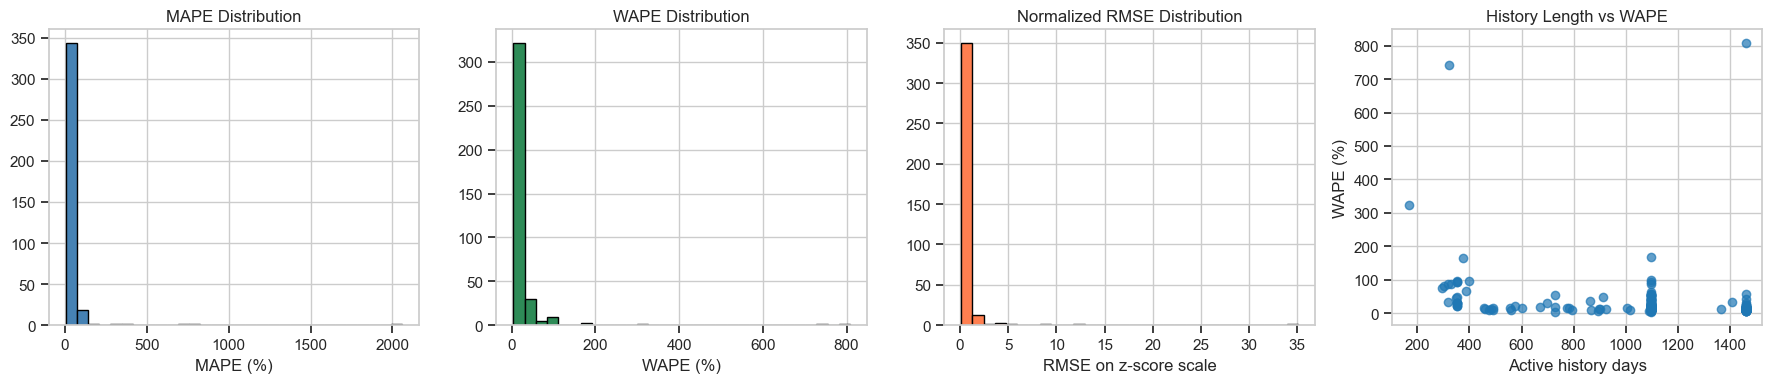

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

if len(successful_metrics) > 0:
    successful_metrics["mape_pct"].hist(bins=30, ax=axes[0], color="steelblue", edgecolor="black")
    axes[0].set_title("MAPE Distribution")
    axes[0].set_xlabel("MAPE (%)")

    successful_metrics["wape_pct"].hist(bins=30, ax=axes[1], color="seagreen", edgecolor="black")
    axes[1].set_title("WAPE Distribution")
    axes[1].set_xlabel("WAPE (%)")

    successful_metrics["rmse_norm"].hist(bins=30, ax=axes[2], color="coral", edgecolor="black")
    axes[2].set_title("Normalized RMSE Distribution")
    axes[2].set_xlabel("RMSE on z-score scale")

    axes[3].scatter(successful_metrics["history_days"], successful_metrics["wape_pct"], alpha=0.7)
    axes[3].set_title("History Length vs WAPE")
    axes[3].set_xlabel("Active history days")
    axes[3].set_ylabel("WAPE (%)")
else:
    for ax in axes:
        ax.text(0.5, 0.5, "No successful models", ha="center", va="center")

plt.tight_layout()

In [17]:
if len(successful_metrics) > 0:
    display(successful_metrics.nsmallest(10, "wape_pct")[[
        "client", "n_obs", "history_days", "mae", "rmse", "mape_pct", "wape_pct", "mae_norm", "rmse_norm"
    ]])
    display(successful_metrics.nlargest(10, "wape_pct")[[
        "client", "n_obs", "history_days", "mae", "rmse", "mape_pct", "wape_pct", "mae_norm", "rmse_norm"
    ]])

,client,n_obs,history_days,mae,rmse,mape_pct,wape_pct,mae_norm,rmse_norm
0,MT_145,26305,1096.000000,2.848640,3.342281,4.341786,4.262340,0.486216,0.570472
1,MT_152,17521,730.000000,49.976797,60.724842,4.532879,4.541699,0.450938,0.547917
2,MT_146,26145,1089.333333,4.453816,5.203722,5.503990,5.404380,0.555960,0.649569
3,MT_148,26305,1096.000000,21.659161,23.868392,6.105088,6.124888,0.835469,0.920686
4,MT_229,35065,1461.000000,60.774564,85.880010,6.966348,6.182912,0.223542,0.315885
5,MT_150,26305,1096.000000,1.439113,1.692676,6.186405,6.194017,0.338900,0.398612
6,MT_147,26305,1096.000000,159.585376,184.700845,6.670322,6.659637,0.635172,0.735135
7,MT_182,35065,1461.000000,3.192722,4.951690,7.831448,6.978077,0.211634,0.328230
8,MT_369,26305,1096.000000,53.232382,68.206951,7.276450,7.030643,0.385414,0.493833
9,MT_176,35065,1461.000000,5.652843,9.590011,8.764468,7.516674,0.199480,0.338417


,client,n_obs,history_days,mae,rmse,mape_pct,wape_pct,mae_norm,rmse_norm
369,MT_223,35065,1461.0,43.119058,55.328471,808.482338,808.482338,0.189748,0.206657
368,MT_112,7753,323.0,425.625820,550.549112,730.007373,742.616079,27.098546,35.052104
367,MT_178,4009,167.0,1527.343984,1843.167630,370.545025,324.554587,9.885664,11.929818
366,MT_093,26305,1096.0,37.853333,50.866424,820.962425,167.115238,0.649525,0.858244
365,MT_179,9049,377.0,126.534517,145.015131,191.663546,165.299240,4.975444,5.702118
364,MT_001,26305,1096.0,2.253766,2.377257,99.753309,99.735833,1.345155,1.408269
363,MT_289,9553,398.0,93.283270,99.228796,108.860830,96.440989,3.275725,3.484507
362,MT_121,8449,352.0,171.643338,188.252967,93.072975,95.168479,4.844089,5.214377
361,MT_117,8449,352.0,3.611616,4.615848,94.085196,94.514844,1.182748,1.400242
360,MT_143,26305,1096.0,87.750141,100.919035,130.336088,92.956139,1.405898,1.616884


## 9. Holdout Forecast Examples

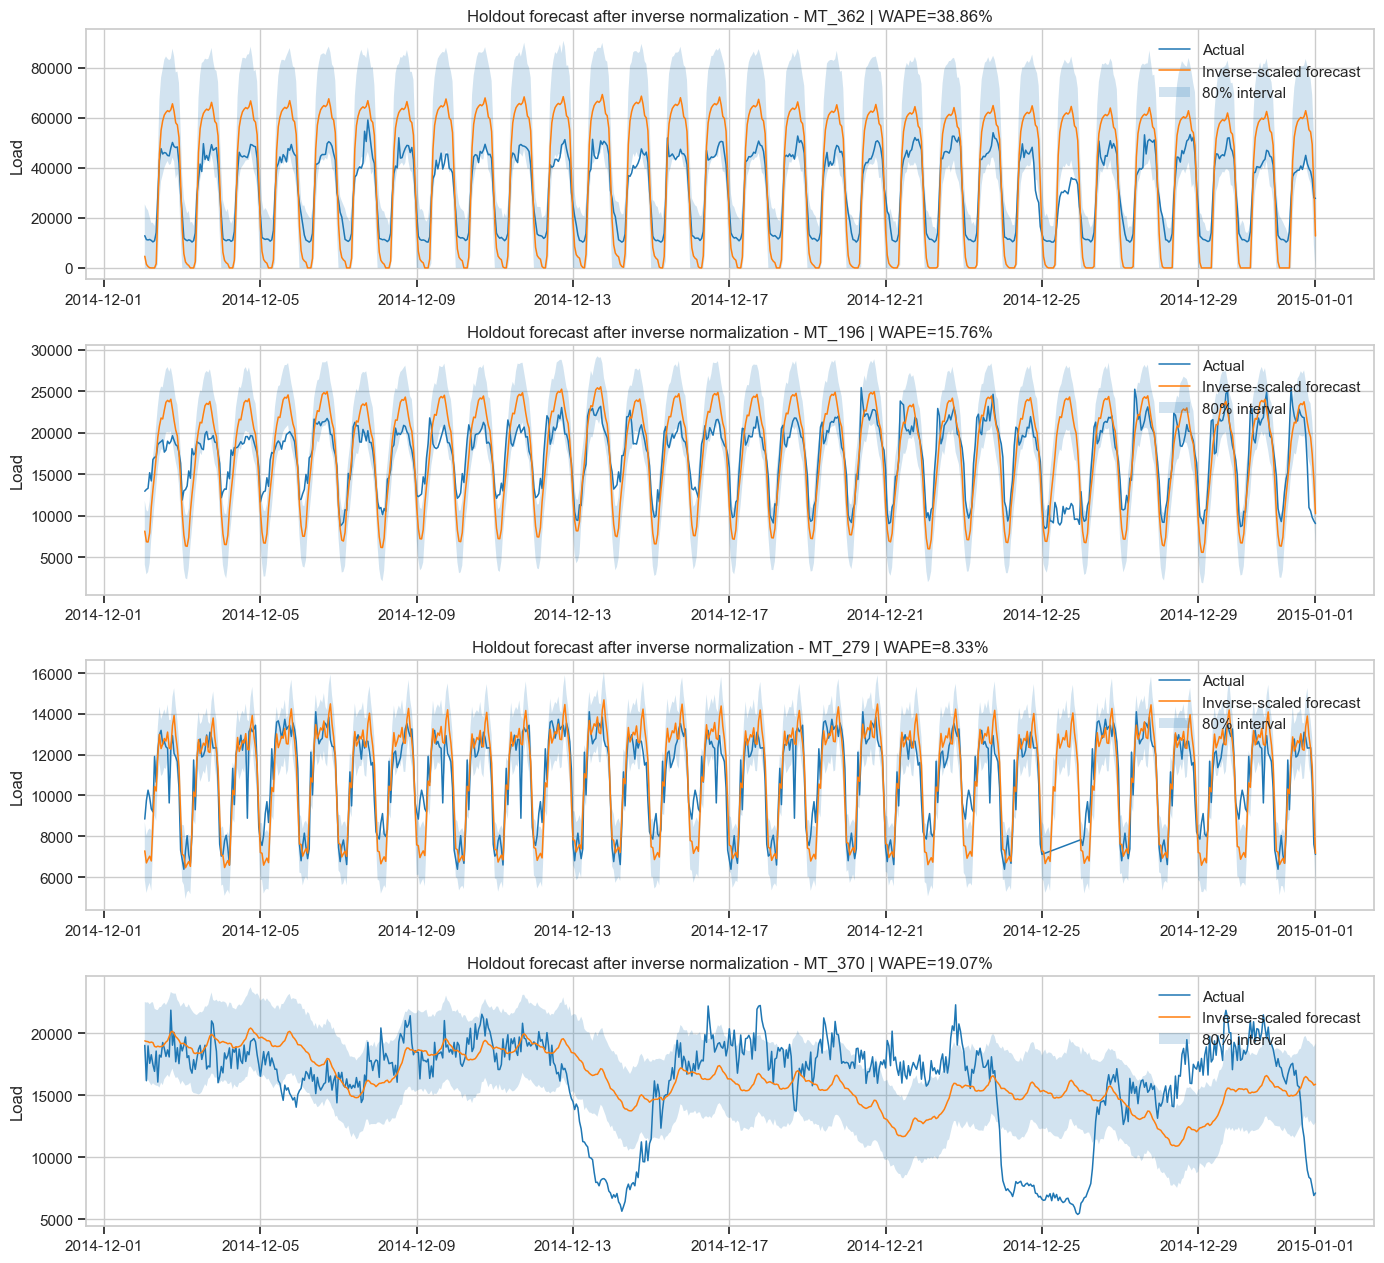

In [18]:
if len(successful_metrics) > 0 and not holdout_predictions_df.empty:
    example_clients = [c for c in top_clients if c in successful_metrics["client"].values][:4]
    if not example_clients:
        example_clients = successful_metrics.head(4)["client"].tolist()

    fig, axes = plt.subplots(len(example_clients), 1, figsize=(14, 3.2 * len(example_clients)), sharex=False)
    if len(example_clients) == 1:
        axes = [axes]

    for ax, client in zip(axes, example_clients):
        temp = holdout_predictions_df[holdout_predictions_df["client"] == client]
        ax.plot(temp["ds"], temp["y"], label="Actual", linewidth=1.1)
        ax.plot(temp["ds"], temp["yhat"], label="Inverse-scaled forecast", linewidth=1.1)
        ax.fill_between(temp["ds"], temp["yhat_lower"], temp["yhat_upper"], alpha=0.2, label="80% interval")
        wape = successful_metrics.loc[successful_metrics["client"] == client, "wape_pct"].iloc[0]
        ax.set_title(f"Holdout forecast after inverse normalization - {client} | WAPE={wape:.2f}%")
        ax.set_ylabel("Load")
        ax.legend(loc="upper right")

    plt.tight_layout()

## 10. Normalized Holdout Examples

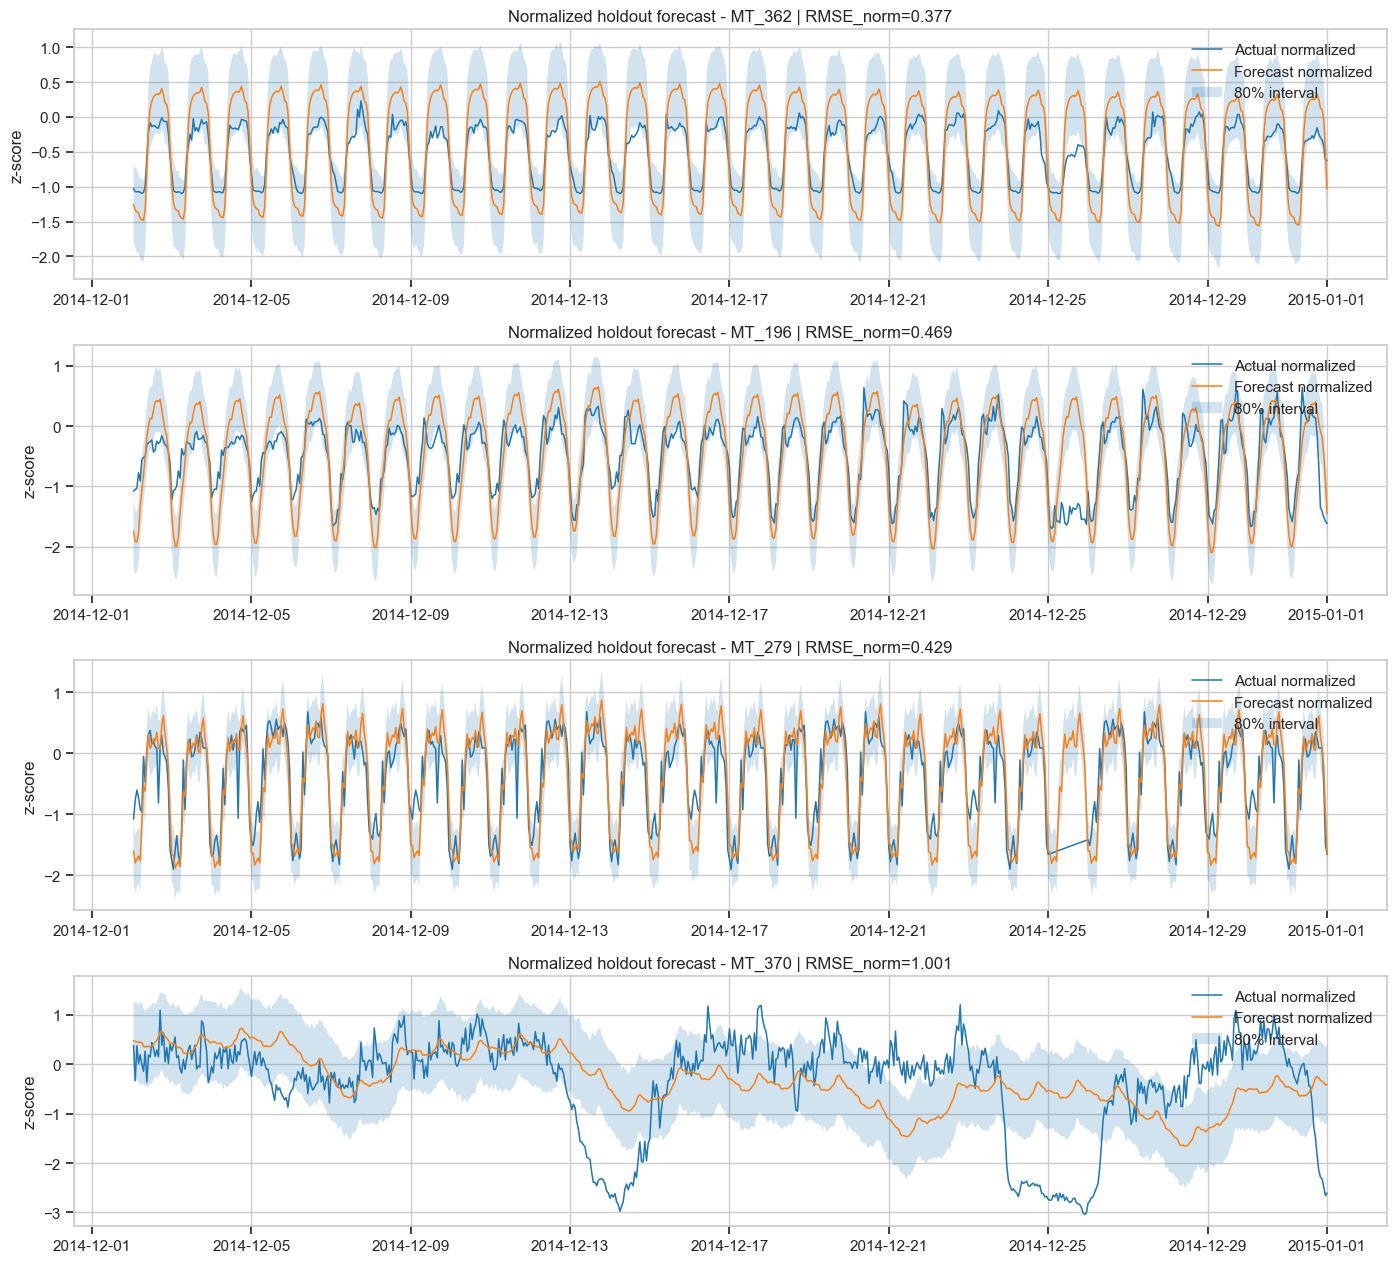

In [19]:
if len(successful_metrics) > 0 and not holdout_predictions_df.empty:
    example_clients = [c for c in top_clients if c in successful_metrics["client"].values][:4]
    if not example_clients:
        example_clients = successful_metrics.head(4)["client"].tolist()

    fig, axes = plt.subplots(len(example_clients), 1, figsize=(14, 3.2 * len(example_clients)), sharex=False)
    if len(example_clients) == 1:
        axes = [axes]

    for ax, client in zip(axes, example_clients):
        temp = holdout_predictions_df[holdout_predictions_df["client"] == client]
        ax.plot(temp["ds"], temp["y_norm"], label="Actual normalized", linewidth=1.1)
        ax.plot(temp["ds"], temp["yhat_norm"], label="Forecast normalized", linewidth=1.1)
        ax.fill_between(temp["ds"], temp["yhat_lower_norm"], temp["yhat_upper_norm"], alpha=0.2, label="80% interval")
        rmse_norm = successful_metrics.loc[successful_metrics["client"] == client, "rmse_norm"].iloc[0]
        ax.set_title(f"Normalized holdout forecast - {client} | RMSE_norm={rmse_norm:.3f}")
        ax.set_ylabel("z-score")
        ax.legend(loc="upper right")

    plt.tight_layout()

## 11. Future Forecast Examples

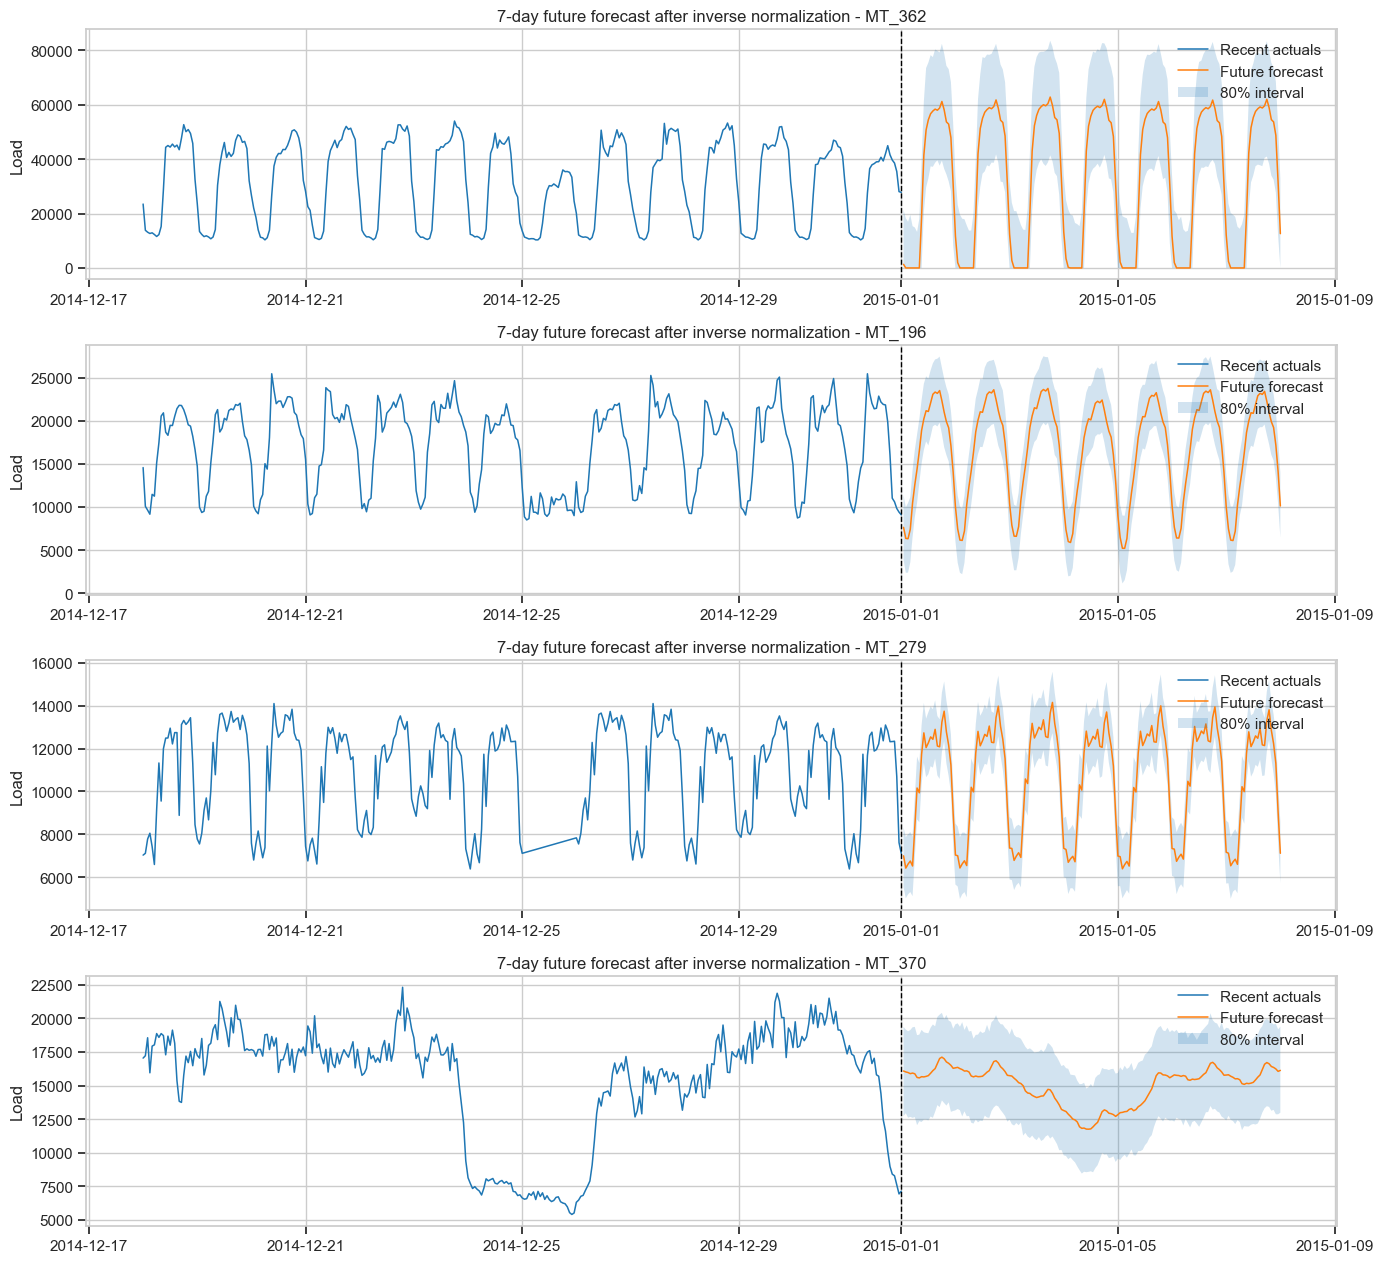

In [20]:
if len(successful_metrics) > 0 and not future_forecasts_df.empty:
    example_clients = [c for c in top_clients if c in successful_metrics["client"].values][:4]
    if not example_clients:
        example_clients = successful_metrics.head(4)["client"].tolist()

    fig, axes = plt.subplots(len(example_clients), 1, figsize=(14, 3.2 * len(example_clients)), sharex=False)
    if len(example_clients) == 1:
        axes = [axes]

    for ax, client in zip(axes, example_clients):
        history_tail = prepare_client_frame(processed_hourly, client)
        history_tail = history_tail[history_tail["ds"] >= history_tail["ds"].max() - pd.Timedelta(days=14)]
        future_temp = future_forecasts_df[future_forecasts_df["client"] == client]

        ax.plot(history_tail["ds"], history_tail["y"], label="Recent actuals", linewidth=1.1)
        ax.plot(future_temp["ds"], future_temp["yhat"], label="Future forecast", linewidth=1.1)
        ax.fill_between(future_temp["ds"], future_temp["yhat_lower"], future_temp["yhat_upper"], alpha=0.2, label="80% interval")
        ax.axvline(history_tail["ds"].max(), color="black", linestyle="--", linewidth=1)
        ax.set_title(f"{FUTURE_DAYS}-day future forecast after inverse normalization - {client}")
        ax.set_ylabel("Load")
        ax.legend(loc="upper right")

    plt.tight_layout()

## 12. Saved Artifacts

The modelling cell writes these CSV files:

- `outputs/prophet_all_normalized/prophet_all_normalized_metrics.csv`
- `outputs/prophet_all_normalized/prophet_all_normalized_holdout_predictions.csv`
- `outputs/prophet_all_normalized/prophet_all_normalized_future_forecasts.csv`
- `outputs/prophet_all_normalized/prophet_all_normalized_metrics_partial.csv`
- `outputs/prophet_all_normalized/prophet_all_normalized_scalers_full_history.csv`

The partial metrics file is updated after every client so that long runs leave progress on disk.


In [21]:
for path in [
    OUTPUT_DIR / "prophet_all_normalized_metrics.csv",
    OUTPUT_DIR / "prophet_all_normalized_holdout_predictions.csv",
    OUTPUT_DIR / "prophet_all_normalized_future_forecasts.csv",
    OUTPUT_DIR / "prophet_all_normalized_metrics_partial.csv",
    OUTPUT_DIR / "prophet_all_normalized_scalers_full_history.csv",
]:
    print(f"{path}: {'exists' if path.exists() else 'not created yet'}")

outputs/prophet_all_normalized/prophet_all_normalized_metrics.csv: exists
outputs/prophet_all_normalized/prophet_all_normalized_holdout_predictions.csv: exists
outputs/prophet_all_normalized/prophet_all_normalized_future_forecasts.csv: exists
outputs/prophet_all_normalized/prophet_all_normalized_metrics_partial.csv: exists
outputs/prophet_all_normalized/prophet_all_normalized_scalers_full_history.csv: exists


## 13. Notes for Next Iteration

This is still a baseline model. Useful extensions would be:

- compare normalized Prophet against the non-normalized Prophet outputs,
- compare against seasonal naive forecasts for every client,
- tune Prophet hyperparameters on representative clients,
- test multiplicative seasonality after normalization only if inverse-scale residuals suggest level-dependent amplitude,
- use rolling-origin cross-validation for selected high-load and low-load clients.
